In [1]:
from diffusion_models.models import diffusion_log as dd
import pandas as pd
import numpy as np
from diffusion_models.utils import common_utils as ut
import arviz as az
import os

/home/rkm160630/anaconda3/envs/ds/lib/python3.10/site-packages/pymc/sampling/jax.py:39: UserWarning: This module is experimental.
  warnings.warn("This module is experimental.")


In [2]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

cpu


In [3]:
rotation_RT = pd.read_csv(f"data/rotation_rt.csv")
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]

rotation_X = pd.read_csv(f"data/rotation_ra.csv")
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [4]:
samples_n, tune, chains, acceptance_rate = 2000, 2000, 4,0.90

posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
samples_n,chains=chains, sampler="PYMC", tune=tune, acceptance_rate = acceptance_rate)


2023-01-13 10:23:33,232 - Common-Utils - DEBUG - [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


DEBUG:Common-Utils:[v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
Auto-assigning NUTS sampler...
INFO:pymc:Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO:pymc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
INFO:pymc:NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


Sampling 4 chains for 2_000 tune and 20_000 draw iterations (8_000 + 80_000 draws total) took 258 seconds.
INFO:pymc:Sampling 4 chains for 2_000 tune and 20_000 draw iterations (8_000 + 80_000 draws total) took 258 seconds.


In [5]:
r_hat = ut.get_rhat(posterior_chain)
r_hat

,"v_m[0, 0]","v_m[0, 1]","v[0, 0]","v[0, 1]","v[1, 0]","v[1, 1]","v[2, 0]","v[2, 1]","v[3, 0]","v[3, 1]",...,"z[92, 0]","z[92, 1]","z[93, 0]","z[93, 1]","z[94, 0]","z[94, 1]","ter_m[0, 0]","ter_m[0, 1]","ter_s[0, 0]","ter_s[0, 1]"
r_hat,3.06,3.05,2.98,2.93,3.69,3.57,3.4,3.43,3.53,2.97,...,3.36,3.58,3.71,3.05,2.94,3.1,3.57,3.02,3.44,3.09


In [6]:
posterior_chain

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

<AxesSubplot: ylabel='Density'>

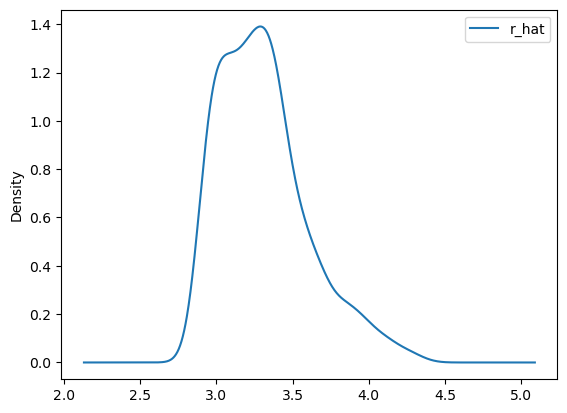

In [7]:
r_hat.T.plot(kind="kde")

In [ ]:
#az.plot_trace(posterior_chain)

In [9]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

,0,1,2,3
0,2.288079,2.460900,0.980062,0.213011
1,0.301843,1.691434,2.697192,2.581728
2,2.163063,3.885441,0.924364,1.295895
3,1.340133,3.137247,2.667246,2.561880
4,2.645371,3.691739,1.555648,1.675414
...,...,...,...,...
3799995,0.775066,2.169116,3.330804,1.959006
3799996,2.900908,2.193386,2.041567,1.384591
3799997,1.978973,2.489920,3.204045,2.218363
3799998,2.683780,3.495557,1.337653,0.640233


In [10]:
v_c_ch.plot(kind="density")

In [ ]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

In [ ]:
a_c_ch.fillna(0).plot(kind="density")